In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sales = pd.read_csv("../artifacts/raw_data/sales_fact.csv")
products = pd.read_csv("../artifacts/raw_data/products_master.csv")
suppliers = pd.read_csv("../artifacts/raw_data/suppliers_master.csv")
inventory = pd.read_csv("../artifacts/raw_data/inventory_snapshot.csv")

In [ ]:
sales["date"] = pd.to_datetime(sales["date"]) # converting string date to date

C:\Users\kk998\AppData\Local\Temp\ipykernel_3896\2049261732.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sales["date"] = pd.to_datetime(sales["date"])


In [ ]:
# Merging sales + product

df = sales.merge(products, on="sku_id", how="left")

In [4]:
# now merging supplier
df = df.merge(suppliers, on="supplier_id", how = "left")

In [5]:
#merging inventory

df = df.merge(inventory, on="sku_id",how ="left")

In [ ]:
df.shape

(14640, 41)

In [9]:
df.head()

,date,sku_id,units_sold,selling_price,gross_revenue,promo_flag,discount_pct,month,week_of_year,day_of_week,...,supplier_id_x,supplier_name,avg_lead_time,lead_time_variability,current_stock,safety_stock,reorder_point,lead_time_days,inbound_shipment_qty,supplier_id_y
0,2024-01-01,SKU0001,28,1028.54,28799.12,0,0.0072,1,1,0,...,SUP003,Skyline Imports Pvt. Ltd.,10,2,963,282,631,10,127,SUP003
1,2024-01-02,SKU0001,27,942.76,25454.52,0,0.0900,1,1,1,...,SUP003,Skyline Imports Pvt. Ltd.,10,2,963,282,631,10,127,SUP003
2,2024-01-03,SKU0001,27,1023.78,27642.06,0,0.0118,1,1,2,...,SUP003,Skyline Imports Pvt. Ltd.,10,2,963,282,631,10,127,SUP003
3,2024-01-04,SKU0001,29,940.90,27286.10,0,0.0918,1,1,3,...,SUP003,Skyline Imports Pvt. Ltd.,10,2,963,282,631,10,127,SUP003
4,2024-01-05,SKU0001,37,812.43,30059.91,1,0.2158,1,1,4,...,SUP003,Skyline Imports Pvt. Ltd.,10,2,963,282,631,10,127,SUP003


In [10]:
df.isnull().sum()

date                        0
sku_id                      0
units_sold                  0
selling_price               0
gross_revenue               0
promo_flag                  0
discount_pct                0
month                       0
week_of_year                0
day_of_week                 0
is_weekend                  0
is_festival_month           0
is_payday_period            0
season_tag                  0
holiday_flag                0
weather_index               0
campaign_intensity          0
platform_traffic_source     0
traffic_index               0
competitor_price_index      0
competitor_stockout_flag    0
bundle_offer_flag           0
stock_visibility_score      0
rating_score                0
review_volume               0
product_visibility_rank     0
sku_name                    0
category                    0
sub_category                0
mrp                         0
cost_price                  0
supplier_id_x               0
supplier_name               0
avg_lead_t

# Visualization

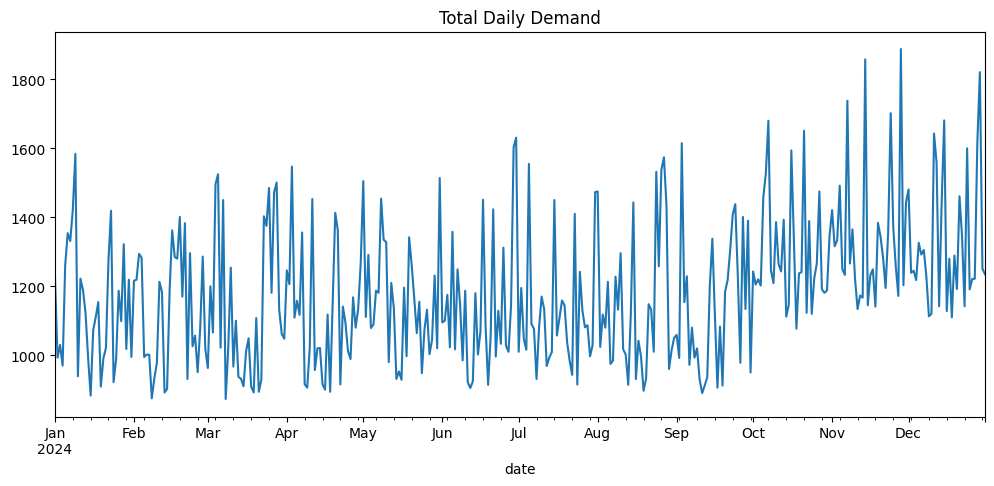

In [19]:
# Total demand over time

daily_sales = df.groupby("date")["units_sold"].sum()
plt.figure(figsize=(12,5))
daily_sales.plot()
plt.title("Total Daily Demand")
plt.show()

<Axes: xlabel='day_of_week', ylabel='units_sold'>

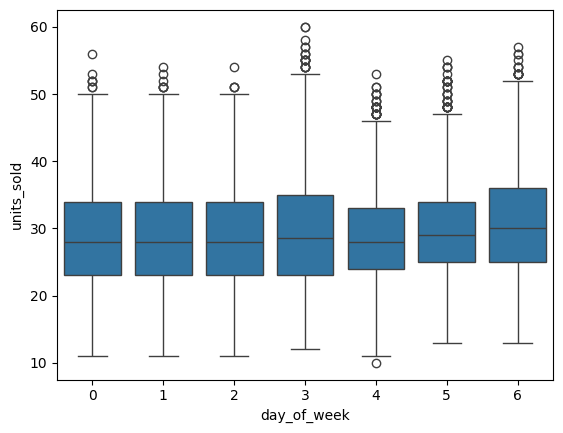

In [ ]:
# weekday vs weekend demand

sns.boxplot(x="day_of_week", y="units_sold", data=df)

<Axes: xlabel='promo_flag', ylabel='units_sold'>

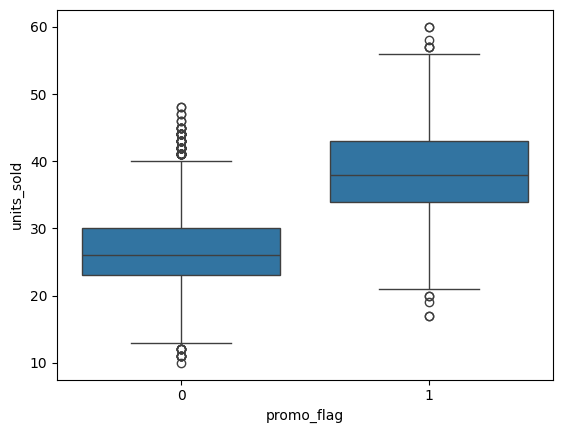

In [18]:
# promotion impact

sns.boxplot(x="promo_flag", y="units_sold", data=df)

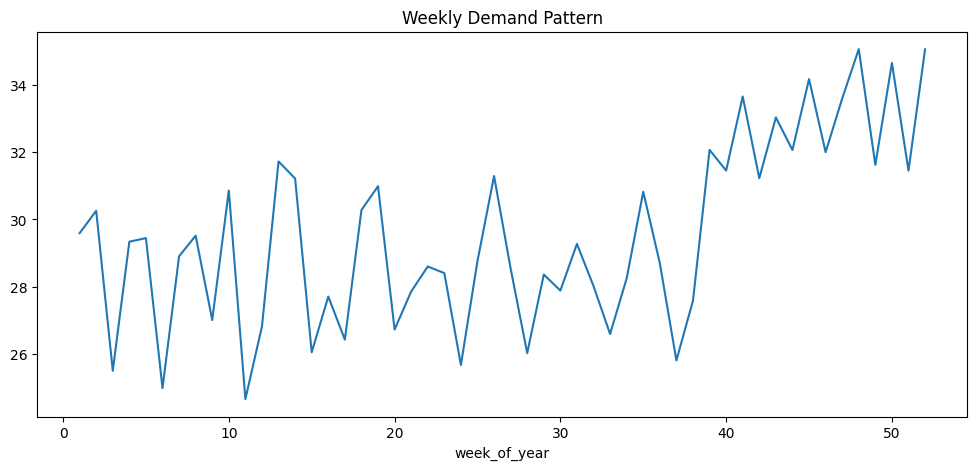

In [20]:
# Demand by week of year

weekly = df.groupby("week_of_year")["units_sold"].mean()

plt.figure(figsize=(12,5))
weekly.plot()
plt.title("Weekly Demand Pattern")
plt.show()

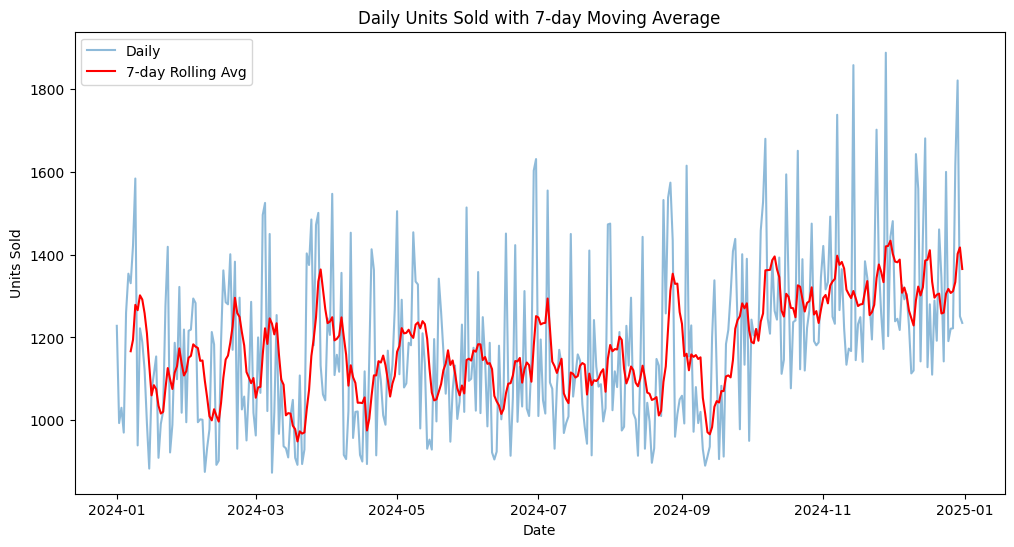

In [21]:
rolling_sales = daily_sales.rolling(window=7).mean()  # 7-day rolling average
plt.figure(figsize=(12,6))
plt.plot(daily_sales.index, daily_sales.values, alpha=0.5, label='Daily')
plt.plot(rolling_sales.index, rolling_sales.values, color='red', label='7-day Rolling Avg')
plt.title("Daily Units Sold with 7-day Moving Average")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

In [24]:
df = df.sort_values(["sku_id","date"])

In [26]:
df.shape
df.isnull().sum()

date                        0
sku_id                      0
units_sold                  0
selling_price               0
gross_revenue               0
promo_flag                  0
discount_pct                0
month                       0
week_of_year                0
day_of_week                 0
is_weekend                  0
is_festival_month           0
is_payday_period            0
season_tag                  0
holiday_flag                0
weather_index               0
campaign_intensity          0
platform_traffic_source     0
traffic_index               0
competitor_price_index      0
competitor_stockout_flag    0
bundle_offer_flag           0
stock_visibility_score      0
rating_score                0
review_volume               0
product_visibility_rank     0
sku_name                    0
category                    0
sub_category                0
mrp                         0
cost_price                  0
supplier_id_x               0
supplier_name               0
avg_lead_t

In [27]:
# using Lag feature for demand casting with the help of previous sales 

df["lag_7"] =df.groupby("sku_id")["units_sold"].shift(7)

In [28]:
df["lag_14"] = df.groupby("sku_id")["units_sold"].shift(14)

In [29]:
df["lag28"] = df.groupby("sku_id")["units_sold"].shift(28)

In [30]:
# Rolling demand feature
df["rolling_mean_7"] = (
    df.groupby("sku_id")["units_sold"].shift(1).rolling(7).mean()
    )

In [31]:
df["rolling_mean_14"] = (
    df.groupby("sku_id")["units_sold"].shift(1).rolling(14).mean()
)

In [32]:
df.isnull().sum()

date                           0
sku_id                         0
units_sold                     0
selling_price                  0
gross_revenue                  0
promo_flag                     0
discount_pct                   0
month                          0
week_of_year                   0
day_of_week                    0
is_weekend                     0
is_festival_month              0
is_payday_period               0
season_tag                     0
holiday_flag                   0
weather_index                  0
campaign_intensity             0
platform_traffic_source        0
traffic_index                  0
competitor_price_index         0
competitor_stockout_flag       0
bundle_offer_flag              0
stock_visibility_score         0
rating_score                   0
review_volume                  0
product_visibility_rank        0
sku_name                       0
category                       0
sub_category                   0
mrp                            0
cost_price

In [33]:
#dropping missing value

df = df.dropna()

In [34]:
df.isnull().sum()

date                        0
sku_id                      0
units_sold                  0
selling_price               0
gross_revenue               0
promo_flag                  0
discount_pct                0
month                       0
week_of_year                0
day_of_week                 0
is_weekend                  0
is_festival_month           0
is_payday_period            0
season_tag                  0
holiday_flag                0
weather_index               0
campaign_intensity          0
platform_traffic_source     0
traffic_index               0
competitor_price_index      0
competitor_stockout_flag    0
bundle_offer_flag           0
stock_visibility_score      0
rating_score                0
review_volume               0
product_visibility_rank     0
sku_name                    0
category                    0
sub_category                0
mrp                         0
cost_price                  0
supplier_id_x               0
supplier_name               0
avg_lead_t

In [35]:
df.shape

(13520, 46)

In [37]:
# prepare feature and targets

x = df.drop(["units_sold","date"],axis=1)  # x -> model inputs
y = df["units_sold"] # y -> predict

In [38]:
# Handle categorical column

x= pd.get_dummies(x, drop_first = True)

In [39]:
split = int(len(df) * 0.8)

X_train = x.iloc[:split]
X_test = x.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [40]:
# training first Model

# simple Linear Regression

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)



LinearRegression()

In [41]:
y_pred = model.predict(X_test)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

print("MAE:",mae)
print("RMSE:",rmse)
print("R2 Score:",r2)

MAE: 2.055813767382198
RMSE: 2.5418653472108765
R2 Score: 0.8953154788408564


In [45]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators= 200,
    max_depth= 10,
    random_state= 42,
    n_jobs= -1
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

In [47]:
#Evaluate

mae_rf = mean_absolute_error(y_test,y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test,y_pred_rf))
r2_rf = r2_score(y_test,y_pred_rf)

print("Random Forest")
print("MAE:",mae_rf)
print("RMSE:",rmse_rf)
print("R2:",r2_rf)

Random Forest
MAE: 2.2974342364574363
RMSE: 2.9344547585830445
R2: 0.8604813625229366


In [48]:
# XGBoost 

from xgboost import XGBRegressor 

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [49]:
# Evaluate
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

MAE: 1.4598805904388428
RMSE: 1.88557800810981
R2: 0.9423941969871521


In [56]:
test_df = X_test.copy()
test_df["actual_demand"] = y_test
test_df["forecast_demand"] = y_pred_xgb
test_df["sku_id"] = df.loc[X_test.index, "sku_id"]

In [57]:
# calculating forecast error

test_df["forecast_error"] = test_df["actual_demand"] - test_df["forecast_demand"]

In [58]:
sku_error_std = test_df.groupby("sku_id")["forecast_error"].std().reset_index()
sku_error_std.columns = ["sku_id","error_std"]

In [59]:
sku_avg_demand = df.groupby("sku_id")["units_sold"].mean().reset_index()
sku_avg_demand.columns = ["sku_id","avg_demand"]

In [60]:
inventory_df = pd.merge(sku_avg_demand, sku_error_std, on="sku_id")

In [ ]:
# Safety Stock = Z × σ × √Lead Time 
#Z = service level factor
#σ = forecast error standard deviation
# Lead Time = supplier lead time

In [61]:
Z = 1.75
lead_time = 7   # example days

inventory_df["safety_stock"] = Z * inventory_df["error_std"] * np.sqrt(lead_time)


In [ ]:
# Reoder Point (ROP)
# ROP = Average Demand × Lead Time + Safety Stock

In [62]:
inventory_df["reorder_point"] = (
    inventory_df["avg_demand"] * lead_time
) + inventory_df["safety_stock"]

In [65]:
inventory_df.round().head()

,sku_id,avg_demand,error_std,safety_stock,reorder_point
0,SKU0033,27.0,2.0,8.0,200.0
1,SKU0034,38.0,2.0,7.0,271.0
2,SKU0035,30.0,2.0,9.0,218.0
3,SKU0036,27.0,1.0,6.0,194.0
4,SKU0037,30.0,2.0,7.0,220.0


In [ ]:
inventory_df.to_csv("artifcats/inventory_policy_output.csv", index=False)

In [69]:
import os
import pickle


os.makedirs("../artifacts", exist_ok=True)

with open("../artifacts/model.pkl", "wb") as f:
    pickle.dump(xgb, f)

In [70]:
inventory_df.to_csv("../artifacts/inventory_policy.csv", index=False)

In [71]:
df.to_csv("../artifacts/final_feature_dataset.csv", index=False)